In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import SurvivalToDischarge

C:\Users\redja\AppData\Local\Temp\ipykernel_12716\3887422243.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## The Data

In [ ]:
X, y = SurvivalToDischarge.load_data(sample_size=40000, icu_vitals=True, top_n_labs=1600)

In [ ]:

# 80/20 train-test, need to switch to train-validate-test once were comparing models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Lasso is scale-sensitive
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

Train: (32000, 85), Test: (8000, 85)


## The Lasso

In [13]:
# Logistic regression with L1 penalty and 10 different regularization strengths
model = LogisticRegressionCV(
    Cs=np.logspace(-4, 1, 10),
    cv=5,
    l1_ratios=(1,),
    solver='saga',
    max_iter=10000,
    n_jobs=-1,
    random_state=42,
)
model.fit(X_train_scaled, y_train)

best_C = model.C_[0]
print(f"Best C: {best_C:.6f}")
print(f"Non-zero coefficients: {np.sum(model.coef_[0] != 0)} / {len(model.coef_[0])}")

c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-le

Best C (= 1/λ): 0.059948  →  λ = 16.6810
Non-zero coefficients: 50 / 85


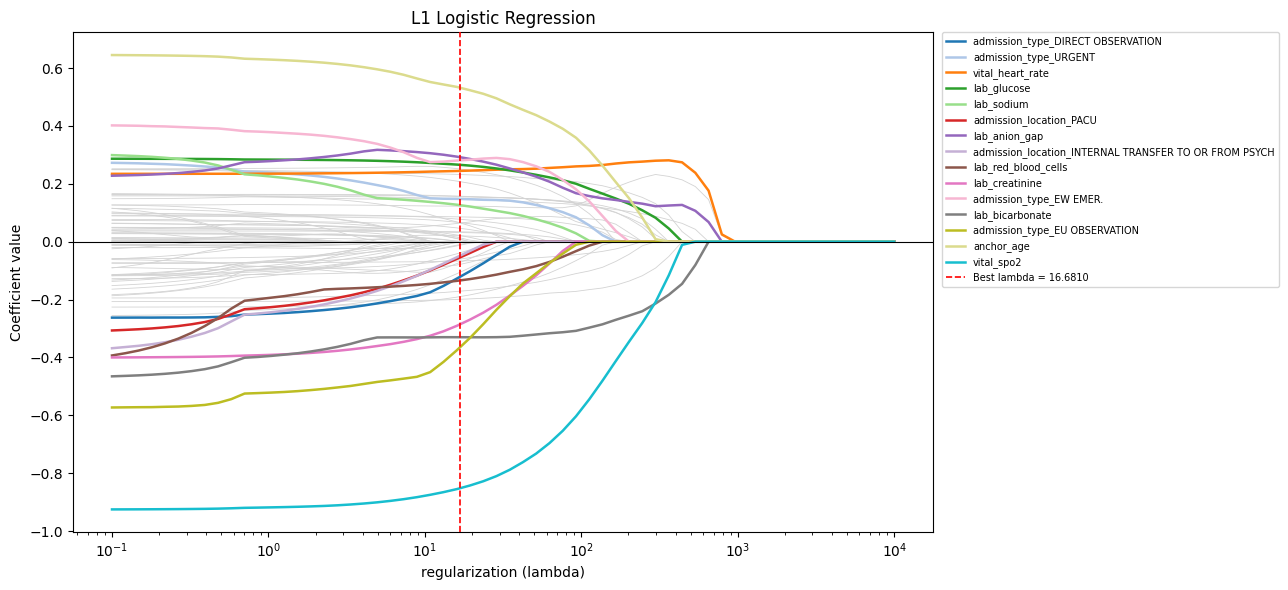

In [ ]:
# This is the one that makes the cool chart where all the lines go to 0

Cs = np.logspace(-4, 1, 60)
coefs_path = []
for C in Cs:
    from sklearn.linear_model import LogisticRegression
    lr = LogisticRegression(C=C, l1_ratios=(1,), solver='saga', max_iter=5_000)
    lr.fit(X_train_scaled, y_train)
    coefs_path.append(lr.coef_[0])
coefs_path = np.array(coefs_path).T
alphas_plot = 1 / Cs # C is 1/lambda

# Only plot the top 15 features in color
top_n = 15
top_idx = np.argsort(np.abs(coefs_path).max(axis=1))[-top_n:]

fig, ax = plt.subplots(figsize=(13, 6))

for i in range(coefs_path.shape[0]):
    ax.plot(alphas_plot, coefs_path[i], color='lightgray', linewidth=0.6, zorder=1)

cmap = plt.cm.tab20
handles, labels = [], []
for rank, i in enumerate(top_idx):
    color = cmap(rank / top_n)
    line, = ax.plot(alphas_plot, coefs_path[i], color=color, linewidth=1.8, zorder=2)
    handles.append(line)
    labels.append(feature_cols[i])

best_lambda = 1 / model.C_[0]
ax.axvline(best_lambda, color='red', linestyle='--', linewidth=1.2, zorder=3)
handles.append(plt.Line2D([0], [0], color='red', linestyle='--', linewidth=1.2))
labels.append(f'Best lambda = {best_lambda:.4f}')

ax.set_xscale('log')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('regularization (lambda)')
ax.set_ylabel('Coefficient value')
ax.set_title('L1 Logistic Regression')
ax.legend(handles, labels, fontsize=7, loc='upper left',
          bbox_to_anchor=(1.01, 1), borderaxespad=0, frameon=True)

plt.tight_layout()
plt.savefig('results/lasso_path.png', dpi=120, bbox_inches='tight')
plt.show()

Confusion matrix:
                Pred 0   Pred 1
  Actual 0        7831        9   (specificity 0.999)
  Actual 1         126       34   (sensitivity 0.212)

TPR (sensitivity):  0.212
FPR (fall-out):     0.001
Precision:          0.791
ROC-AUC:            0.920

              precision    recall  f1-score   support

    Survived       0.98      1.00      0.99      7840
        Died       0.79      0.21      0.33       160

    accuracy                           0.98      8000
   macro avg       0.89      0.61      0.66      8000
weighted avg       0.98      0.98      0.98      8000



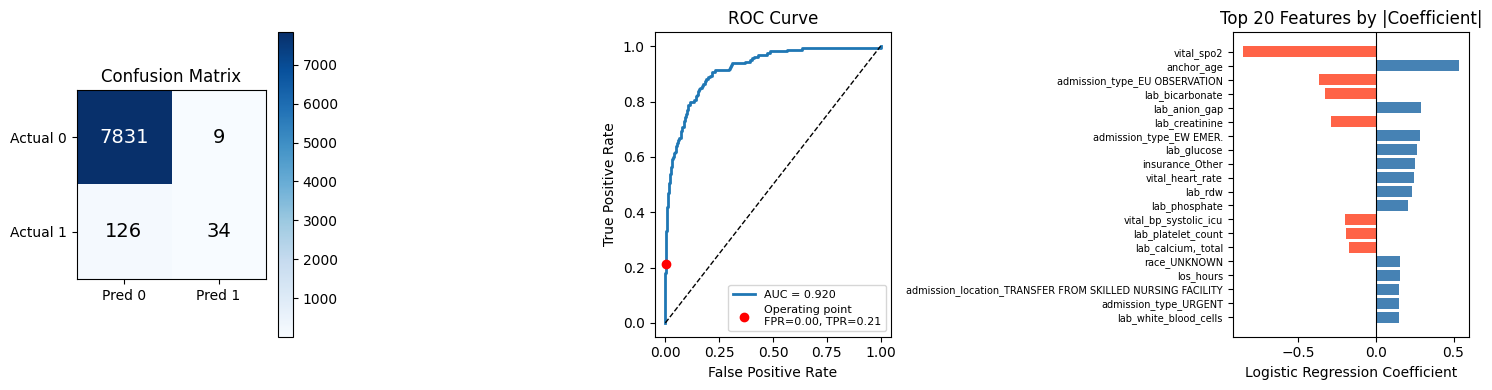

In [18]:
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

# Top feature coefficients
coef_series = pd.Series(model.coef_[0], index=feature_cols)
top_coef = coef_series[coef_series != 0].abs().sort_values(ascending=False).head(20)
signed_top = coef_series[top_coef.index]
colors = ['steelblue' if v > 0 else 'tomato' for v in signed_top]
axes[2].barh(signed_top.index[::-1], signed_top.values[::-1], color=colors[::-1])
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('Logistic Regression Coefficient')
axes[2].set_title('Top 20 Features by |Coefficient|')
axes[2].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('results/lasso_results.png', dpi=120, bbox_inches='tight')
plt.show()